# Tabular Baseline — Metadata-only Biomass Prediction

**Master's in Green Data Science — Practical ML**

Establishes the lower-bound performance using only metadata (NDVI, height,
species, state, month) — no image. This quantifies how much the cheap ground
measurements alone explain biomass, and sets the bar the CNN must beat.

Models: naive median, RandomForest, HistGradientBoosting (course session 7).
Evaluation: StratifiedGroupKFold by image_id, stratified by binned Dry_Total_g
(session 5). Targets trained in log1p space; metrics on the original scale.

## Contents
1. Setup and data
2. Cross-validation folds (leakage check)
3. Baseline evaluation (naive / RF / HGB)
4. Weighted competition score
5. Feature importance
6. Conclusions

## 1. Setup and data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent / "src"))

import config, eda, splits, baseline
%matplotlib inline

df = eda.load_long()
wide = eda.to_wide(df)
wide = eda.group_rare_species(wide, min_count=10)
print("wide:", wide.shape)
print("features:", config.TABULAR_NUM, "+", config.TABULAR_CAT)

wide: (357, 14)
features: ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'month'] + ['State', 'Species_grouped']


## 2. Cross-validation folds

We verify that no image_id appears in both train and test of any fold
(`group_overlap` must be 0) and that mean Total is balanced across folds
(stratification works).

In [2]:
folds = splits.get_cv_folds(wide, n_splits=5)
splits.describe_folds(wide, folds)

,n_train,n_test,test_mean_Total,group_overlap
fold,,,,
0,285,72,51.75,0
1,286,71,37.14,0
2,286,71,48.47,0
3,285,72,44.72,0
4,286,71,44.43,0


## 3. Baseline evaluation

Each model is trained per target in log1p space; predictions are inverted with
expm1 and clipped at 0 (biomass is non-negative). Metrics (RMSE, MAE, R2) are
computed on the original gram scale, averaged over folds.

In [3]:
res = baseline.run_all_baselines(wide, n_splits=5)
res["summary"]

rmse            mae            r2       
                             mean    std    mean    std   mean    std
model        target                                                  
hgb          Dry_Clover_g   8.105  1.881   3.892  0.731  0.538  0.155
             Dry_Dead_g     9.520  2.144   6.122  0.928  0.356  0.152
             Dry_Green_g   12.106  3.787   7.269  1.486  0.745  0.065
             Dry_Total_g   15.434  2.741  10.699  1.200  0.650  0.123
             GDM_g         11.098  2.371   7.543  1.155  0.770  0.063
naive_median Dry_Clover_g  13.151  1.612   6.514  1.181 -0.200  0.068
             Dry_Dead_g    12.737  3.135   8.725  1.760 -0.113  0.058
             Dry_Green_g   25.166  7.454  17.649  4.089 -0.071  0.062
             Dry_Total_g   28.038  6.210  20.528  3.487 -0.079  0.079
             GDM_g         24.964  7.257  17.902  4.015 -0.095  0.091
rf           Dry_Clover_g   7.010  1.747   3.513  0.657  0.653  0.131
             Dry_Dead_g     9.306  1.991   5.820  0.809  0.390  0.117
             Dry_Green_g   11.050  3.722   6.644  1.479  0.794  0.037
             Dry_Total_g   13.903  2.047   9.719  0.838  0.720  0.075
             GDM_g         10.700  3.002   7.079  1.204  0.795  0.028

Per-target view for the main target (Dry_Total_g, competition weight 0.5):

In [4]:
res["summary"].xs("Dry_Total_g", level="target")

rmse            mae            r2       
                mean    std    mean    std   mean    std
model                                                   
hgb           15.434  2.741  10.699  1.200  0.650  0.123
naive_median  28.038  6.210  20.528  3.487 -0.079  0.079
rf            13.903  2.047   9.719  0.838  0.720  0.075

## 4. Weighted competition score

Weighted RMSE across targets (weights 0.1/0.1/0.1/0.2/0.5), lower is better.
The naive median is the reference floor — RF/HGB must beat it to be useful.

In [5]:
res["weighted"]

,weighted_rmse
model,
rf,11.828
hgb,12.910
naive_median,24.117


## 5. Feature importance

Which metadata features drive the prediction. Expectation from EDA: Height and
NDVI dominate (they correlate most with biomass).

In [6]:
baseline.feature_importance(wide, target="Dry_Total_g", kind="rf")

,feature,importance
0,Height_Ave_cm,0.573629
1,Pre_GSHH_NDVI,0.244423
2,month,0.056578
3,Species_grouped_Lucerne,0.031539
4,Species_grouped_Ryegrass,0.024586
5,State_Vic,0.011666
6,Species_grouped_Other,0.009661
7,Species_grouped_Ryegrass_Clover,0.009218
8,Species_grouped_Fescue,0.007579
9,State_Tas,0.006878


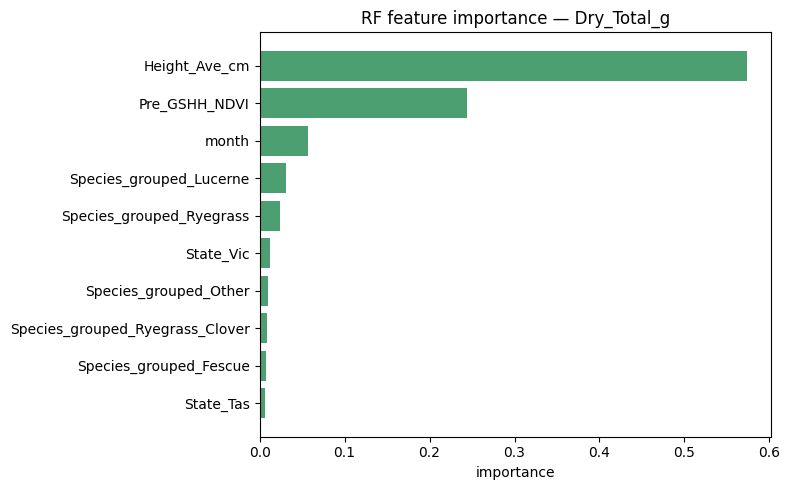

In [ ]:
import matplotlib.pyplot as plt
fi = baseline.feature_importance(wide, "Dry_Total_g", "rf").head(10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#4c9f70")
ax.set_title("RF feature importance — Dry_Total_g")
ax.set_xlabel("importance")
fig.tight_layout(); plt.show()

## 6. Conclusions

*(Fill in from the real numbers above.)*

- Best tabular model and its weighted score vs the naive floor.
- R2 on Dry_Total_g — how much variance metadata explains (expected ~0.4-0.55
  given EDA correlations). The remaining gap is the headroom for the image.
- Top features (expected: Height_Ave_cm, Pre_GSHH_NDVI) — consistent with EDA.
- Hardest target (expected: Dry_Clover_g — many zeros, weak metadata link).
- This baseline is the bar the CNN and fusion models must beat; the image is
  justified only if it closes part of the unexplained variance.